<a href="https://colab.research.google.com/github/jferreira04-cloud/Calculo_num-rico_lobosco/blob/main/ATIVIDADE_COMPUTACIONAL_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nova seção
Aluno: José Luiz de Oliveira Ferreira / Turma: NB / Data: (26/08/2026)
       


x1 = 3.14159265 
n = 0 Truncado: 3  Arredondado: 3
   Ea: 0.14159265 Er: 0.04507034  E%: 4.507034%
n = 1 Truncado: 3.1  Arredondado: 3.1
   Ea: 0.04159265 Er: 0.01323935  E%: 1.323935%
n = 2 Truncado: 3.14  Arredondado: 3.14
   Ea: 0.00159265 Er: 0.00050696  E%: 0.050696%
n = 3 Truncado: 3.141  Arredondado: 3.142
   Ea: 0.00059265 Er: 0.00018865  E%: 0.018865%
n = 4 Truncado: 3.1415  Arredondado: 3.1416
   Ea: 0.00009265 Er: 0.00002949  E%: 0.002949%

x2 = 98.76543 
n = 0 Truncado: 98  Arredondado: 99
   Ea: 0.76543000 Er: 0.00774998  E%: 0.774998%
n = 1 Truncado: 98.7  Arredondado: 98.8
   Ea: 0.06543000 Er: 0.00066248  E%: 0.066248%
n = 2 Truncado: 98.76  Arredondado: 98.77
   Ea: 0.00543000 Er: 0.00005498  E%: 0.005498%
n = 3 Truncado: 98.765  Arredondado: 98.765
   Ea: 0.00043000 Er: 0.00000435  E%: 0.000435%
n = 4 Truncado: 98.7654  Arredondado: 98.7654
   Ea: 0.00003000 Er: 0.00000030  E%: 0.000030%

x3 = 0.00498765 
n = 0 Truncado: 0  Arredondado: 0
   Ea: 0.00498765 Er: 1.0000

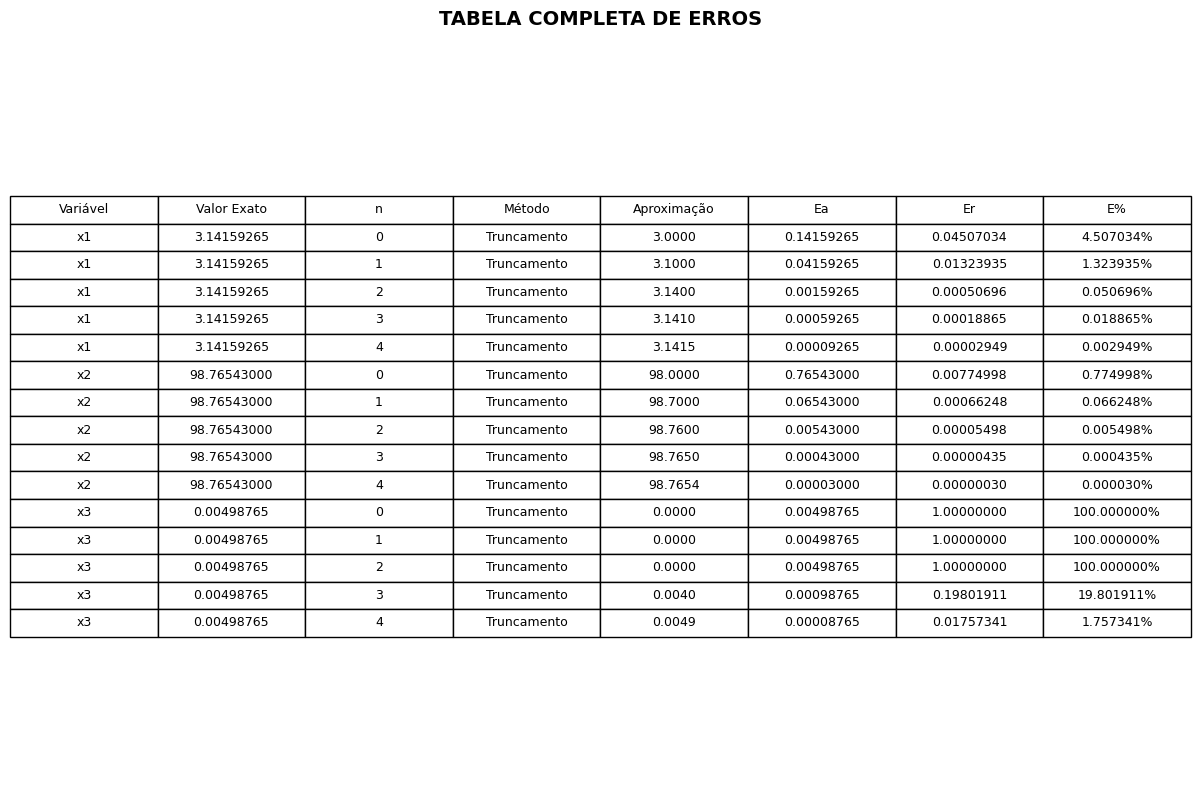

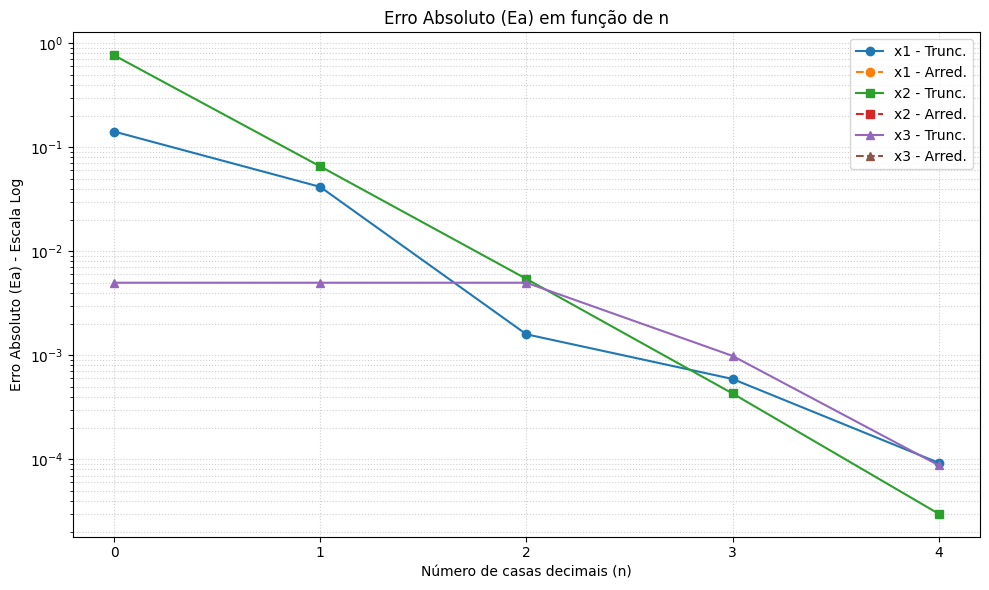

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd

# Define uma função para truncar um número em determinada quantidade de casas.
def truncar(numero, casas):
    fator = 10**casas
 # Trunca o número deslocado e devolve a vírgula à posição original.
    return math.trunc(numero * fator) / fator

# 2. Dados
valores = {"x1": 3.14159265, "x2": 98.76543, "x3": 0.00498765}
casas_n = [0, 1, 2, 3, 4]

resultados = []

# 3. Processamento de todos os valores e casas (n)
for nome_x, x_exato in valores.items():
    print(f"\n{nome_x} = {x_exato} ")

    for n in casas_n:
        # A FUNÇÃO TRUNCAR E O ROUND NATIVO:
        v_trunc = truncar(x_exato, n)
        v_arred = round(x_exato, n)

        print(f"n = {n} Truncado: {v_trunc:.{n}f}  Arredondado: {v_arred:.{n}f}")


# PARTE A2) Erros do Truncamento
        Ea_trunc = abs(x_exato - v_trunc)
        Er_trunc = Ea_trunc / abs(x_exato)
        Ep_trunc = Er_trunc * 100

        print(
            f"   Ea: {Ea_trunc:.8f} Er: {Er_trunc:.8f}  E%: {Ep_trunc:.6f}%"
        )

        resultados.append(
            {
                "Variável": nome_x,
                "Valor Exato": x_exato,
                "n": n,
                "Método": "Truncamento",
                "Aproximação": v_trunc,
                "Ea": Ea_trunc,
                "Er": Er_trunc,
                "E%": Ep_trunc,
            }
        )
     # Parte A3)


   # 4. TABELA COMPLETA (Item 3) em linha de código
df = pd.DataFrame(resultados)
print("\n" "TABELA COMPLETA " )
print(df.to_string(index=False))

  # 4. TABELA COMPLETA (Item 3) em imagem
df = pd.DataFrame(resultados)

# Cria uma figura para desenhar a tabela
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis("off")  # Esconde os eixos do gráfico

# Formata os números da tabela para não ficarem com dígitos infinitos na imagem
df_formatado = df.copy()
df_formatado["Valor Exato"] = df_formatado["Valor Exato"].apply(
    lambda x: f"{x:.8f}"
)
df_formatado["Aproximação"] = df_formatado["Aproximação"].apply(
    lambda x: f"{x:.4f}"
)
df_formatado["Ea"] = df_formatado["Ea"].apply(lambda x: f"{x:.8f}")
df_formatado["Er"] = df_formatado["Er"].apply(lambda x: f"{x:.8f}")
df_formatado["E%"] = df_formatado["E%"].apply(lambda x: f"{x:.6f}%")

# Desenha a tabela na imagem
tabela = ax.table(
    cellText=df_formatado.values,
    colLabels=df_formatado.columns,
    cellLoc="center",
    loc="center",
)

# Ajusta o tamanho da fonte e escala das células
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.2, 1.4)

plt.title("TABELA COMPLETA DE ERROS", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()

# Salva a imagem no seu computador (opcional)
plt.savefig("tabela_resultados.png", dpi=300, bbox_inches="tight")

# Exibe a imagem da tabela na tela
plt.show()



# 5. GRÁFICO LOGARÍTMICO (Item 4)
plt.figure(figsize=(10, 6))
estilos = {"x1": "o", "x2": "s", "x3": "^"}

for nome_x in valores.keys():
    df_trunc = df[(df["Variável"] == nome_x) & (df["Método"] == "Truncamento")]
    plt.plot(
        df_trunc["n"],
        df_trunc["Ea"],
        marker=estilos[nome_x],
        linestyle="-",
        label=f"{nome_x} - Trunc.",
    )

    df_arr = df[(df["Variável"] == nome_x) & (df["Método"] == "Arredondamento")]
    plt.plot(
        df_arr["n"],
        df_arr["Ea"],
        marker=estilos[nome_x],
        linestyle="--",
        label=f"{nome_x} - Arred.",
    )

plt.yscale("log")
plt.xlabel("Número de casas decimais (n)")
plt.ylabel("Erro Absoluto (Ea) - Escala Log")
plt.title("Erro Absoluto (Ea) em função de n")
plt.xticks(casas_n)
plt.grid(True, which="both", linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



In [1]:
#B1

import math
import numpy as np
import pandas as pd

# Dados originais
x_orig = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)

# Séries aproximadas
x_arred = np.array([round(val) for val in x_orig])
x_trunc = np.array([math.trunc(val) for val in x_orig])

series = {
    "Série 1 (Originais)": x_orig,
    "Série 2 (Arredondados)": x_arred,
    "Série 3 (Truncados)": x_trunc,
}

media_ref = np.mean(x_orig)
res = []

print(f"Média de Referência (Originais): {media_ref:.4f}\n")

for nome, s in series.items():
    media = np.mean(s)
    minimo = np.min(s)
    maximo = np.max(s)
    amplitude = maximo - minimo
    dp_amostral = np.std(s, ddof=1)  # ddof=1 para desvio-padrão amostral

    # Erros da média
    Ea = abs(media_ref - media)
    Er = Ea / abs(media_ref)
    Ep = Er * 100

    res.append(
        {
            "Série": nome,
            "Média": media,
            "Mínimo": minimo,
            "Máximo": maximo,
            "Amplitude": amplitude,
            "Desvio-Padrão": dp_amostral,
            "Ea": Ea,
            "Er": Er,
            "E%": Ep,
        }
    )

df_b1 = pd.DataFrame(res)
print(df_b1.to_string(index=False))


#B2

Média de Referência (Originais): 121.1200

                 Série  Média  Mínimo  Máximo  Amplitude  Desvio-Padrão   Ea       Er       E%
   Série 1 (Originais) 121.12   119.8   122.4        2.6       0.833733 0.00 0.000000 0.000000
Série 2 (Arredondados) 121.10   120.0   122.0        2.0       0.875595 0.02 0.000165 0.016513
   Série 3 (Truncados) 120.70   119.0   122.0        3.0       0.948683 0.42 0.003468 0.346764


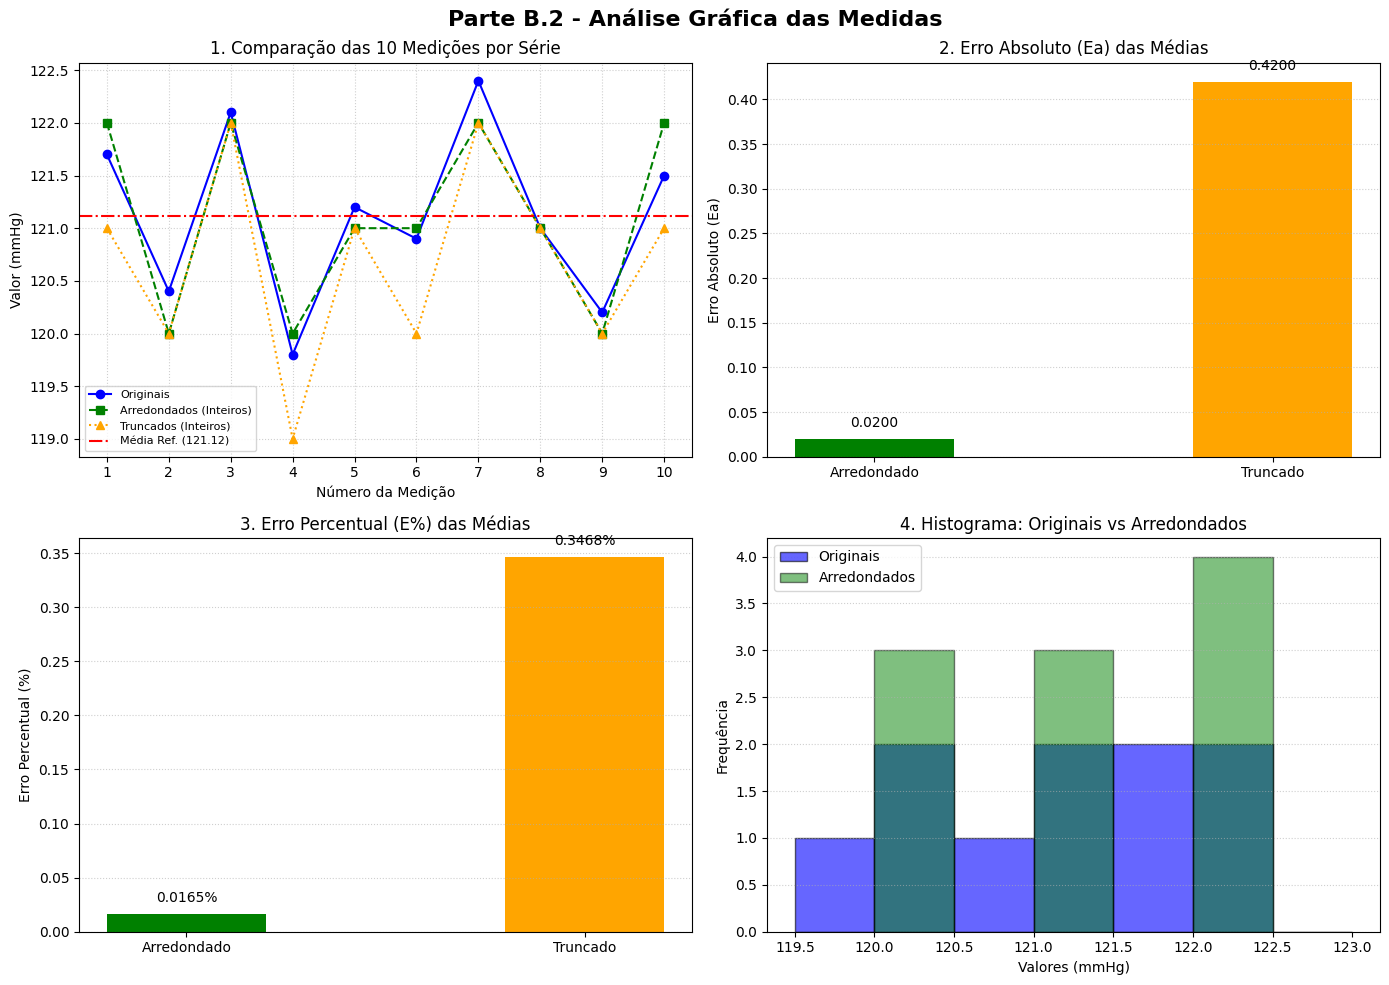

In [2]:
import math
import matplotlib.pyplot as plt
import numpy as np

# Dados das 4 séries (incluindo a de truncados)
x_orig = np.array(
    [121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5]
)
x_arred = np.array([round(val) for val in x_orig])
x_trunc = np.array([math.trunc(val) for val in x_orig])
indices = np.arange(1, 11)  # Medições de 1 a 10

# Médias e Erros
m_ref = np.mean(x_orig)
m_arr = np.mean(x_arred)
m_tru = np.mean(x_trunc)

Ea_arr, Ea_tru = abs(m_ref - m_arr), abs(m_ref - m_tru)
Ep_arr, Ep_tru = (Ea_arr / m_ref) * 100, (Ea_tru / m_ref) * 100

# Configuração da figura com subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Parte B.2 - Análise Gráfica das Medidas", fontsize=16, fontweight="bold"
)

# 1. Gráfico das dez medições (4 Séries)
axs[0, 0].plot(
    indices, x_orig, "o-", label="Originais", color="blue", linewidth=1.5
)
axs[0, 0].plot(
    indices,
    x_arred,
    "s--",
    label="Arredondados (Inteiros)",
    color="green",
    linewidth=1.5,
)
axs[0, 0].plot(
    indices,
    x_trunc,
    "^:",
    label="Truncados (Inteiros)",
    color="orange",
    linewidth=1.5,
)
axs[0, 0].axhline(
    m_ref, color="red", linestyle="-.", label=f"Média Ref. ({m_ref:.2f})"
)
axs[0, 0].set_title("1. Comparação das 10 Medições por Série")
axs[0, 0].set_xlabel("Número da Medição")
axs[0, 0].set_ylabel("Valor (mmHg)")
axs[0, 0].set_xticks(indices)
axs[0, 0].grid(True, linestyle=":", alpha=0.6)
axs[0, 0].legend(fontsize=8)

# 2. Gráfico de barras dos Erros Absolutos das Médias
metodos = ["Arredondado", "Truncado"]
erros_abs = [Ea_arr, Ea_tru]
bars1 = axs[0, 1].bar(metodos, erros_abs, color=["green", "orange"], width=0.4)
axs[0, 1].set_title("2. Erro Absoluto (Ea) das Médias")
axs[0, 1].set_ylabel("Erro Absoluto (Ea)")
axs[0, 1].grid(True, axis="y", linestyle=":", alpha=0.6)
for bar in bars1:
    yval = bar.get_height()
    axs[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.01,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
    )

# 3. Gráfico de barras dos Erros Percentuais das Médias
erros_perc = [Ep_arr, Ep_tru]
bars2 = axs[1, 0].bar(metodos, erros_perc, color=["green", "orange"], width=0.4)
axs[1, 0].set_title("3. Erro Percentual (E%) das Médias")
axs[1, 0].set_ylabel("Erro Percentual (%)")
axs[1, 0].grid(True, axis="y", linestyle=":", alpha=0.6)
for bar in bars2:
    yval = bar.get_height()
    axs[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.008,
        f"{yval:.4f}%",
        ha="center",
        va="bottom",
    )

# 4. Histograma dos Dados Originais e Inteiros Arredondados
bins = np.arange(119.5, 123.5, 0.5)
axs[1, 1].hist(
    x_orig,
    bins=bins,
    alpha=0.6,
    label="Originais",
    color="blue",
    edgecolor="black",
)
axs[1, 1].hist(
    x_arred,
    bins=bins,
    alpha=0.5,
    label="Arredondados",
    color="green",
    edgecolor="black",
)
axs[1, 1].set_title("4. Histograma: Originais vs Arredondados")
axs[1, 1].set_xlabel("Valores (mmHg)")
axs[1, 1].set_ylabel("Frequência")
axs[1, 1].grid(True, axis="y", linestyle=":", alpha=0.6)
axs[1, 1].legend()

plt.tight_layout()
plt.show()